# Parametric Rainfall Insurance — Stochastic Loss Simulation for Weather-Linked Products
### Stochastic Rain Paths

This is the second notebook of the project **"Parametric Rainfall Insurance — Stochastic Loss Simulation for Weather-Linked Products"**

This notebook attempts to simulate stochastic rainfall paths for 366 days. We fit a Tweedie Distribution to rainfall data in the first notebook. For simulating the rainfall each day, we estimate the path for the parameter 'mu' of the Tweedie Distribution. This is a discrete stochastic process: $\mu_{t} = \bar{\mu_{t}} + X_{t}$. $\bar{\mu_{t}}$ is the observed average daily rainfall across 30 years data. 

The notebook fits a AR(1) time series to $X_{t}$ and then simulates paths for $\mu_{t}$. Using these $\mu_{t}$ paths, we simulate rainfall on a given day using the Tweedie Distribution (prameters being: $\mu$ as the simulated $\mu_{t}$ paths, power parameter as 1.90, and $\phi$ as fitted from Notebook 01 of this project). 

We validate the model using plots for distribution of rainfall in the month of July. 

In [69]:
#Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import datetime
from tweedie import tweedie
import import_ipynb
import importlib
import random
import warnings

In [2]:
#Import other notebooks from the project
rainfall_distribution_notebook = importlib.import_module("01_RainfallDistribution")

In [3]:
#Rainfall Data loaded
rainfall_data_ts = rainfall_distribution_notebook.rainfall_data
#Use data from 2004 to 2024 for time series analysis
rainfall_data_ts = rainfall_data_ts[rainfall_data_ts[' YEAR']>=2004]

In [35]:
#Assumed path for mu_t is:
#mu_t = mu_t\bar + (X_t)
#mu_t - mu_t\bar = X_t
rainfall_data_ts.loc[:, ' Xt'] = rainfall_data_ts[' PRECIPITATION'] - rainfall_data_ts[' AVG_RAINFALL']
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)

In [5]:
#Confirm stationarity of the time series using adfuller test
from statsmodels.tsa.stattools import adfuller

result = adfuller(rainfall_data_ts[' Xt'])

if __name__=='__main__':
    print("ADF statistic:", result[0])
    print("p-value:", result[1])

ADF statistic: -72.66409396482797
p-value: 0.0


p-value is 0, the process $X_{t}$ is stationary.

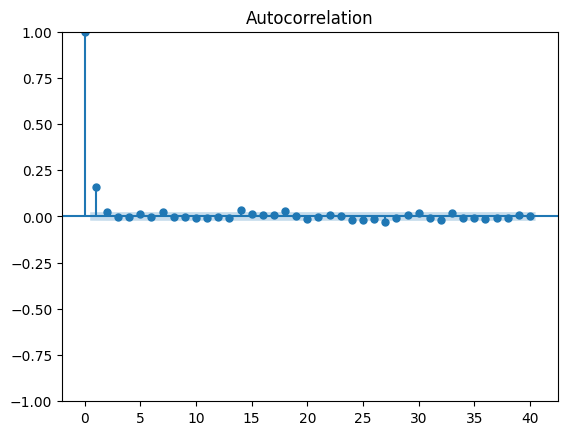

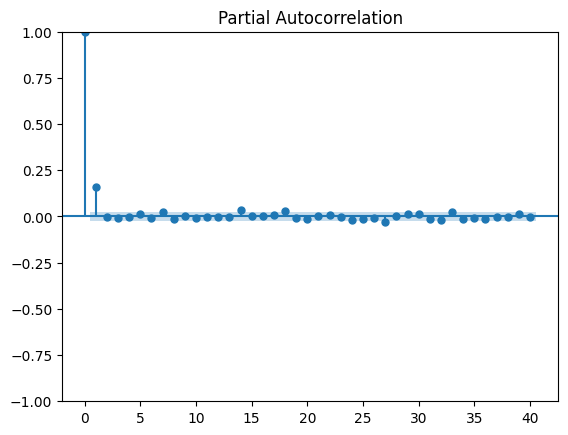

In [6]:
#Plotting ACF and PACF to check which process Xt follows
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
if __name__=='__main__':
    plot_acf(rainfall_data_ts[' Xt'], lags=40)
    plot_pacf(rainfall_data_ts[' Xt'], lags=40)

Both the ACF and PACF display a small spike at lag 1 and negligible autocorrelation beyond that. The similarity between the two functions reflects weak temporal dependence in the residual series rather than indicating a higher-order ARMA process. Given the low magnitude of autocorrelations, a simple AR(1) specification is sufficient to capture the limited persistence present.

In [21]:
#Fitting AR(1) on Xt
from statsmodels.tsa.ar_model import AutoReg
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning

ts = rainfall_data_ts[' Xt']
ts.index = rainfall_data_ts[' DATE']

ar1_model = AutoReg(ts, lags=1).fit()

phi_ar1 = ar1_model.params[1]
sigma_ar1 = np.sqrt(ar1_model.sigma2)

# Suppress statsmodels ValueWarning (no frequency)
warnings.filterwarnings("ignore", category=ValueWarning)

# Suppress pandas FutureWarning (Series indexing)
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
#Simulate paths for Xt
#Xt = phi*X_(t-1) + e_t
#The AR(1) process assumes Gaussian innovations for tractability, although rainfall deviations may exhibit non-normal characteristics such as skewness and heavy tails. 
number_of_paths = 1000
number_of_days = 366

Xt_paths = np.zeros((number_of_paths, number_of_days+1))
Xt_paths[:,0]=0 #X_0=0

for i in range(number_of_paths):
    for j in range(1,number_of_days):
        Xt_paths[i,j] = phi_ar1*Xt_paths[i,j-1]+np.random.normal(0,sigma_ar1)
        

In [15]:
#Simulate paths for mu_t
avg_rainfall = np.array(rainfall_data_ts[' AVG_RAINFALL'][:366])

mu_t_paths = np.zeros((number_of_paths, number_of_days))
for i in range(number_of_paths):
    for j in range(number_of_days):
        mu_t_paths[i,j] = np.maximum(avg_rainfall[j]+Xt_paths[i,j+1],1e-6)

In [29]:
#Simulate daily rainfall for the next year
np.random.seed(43)

rainfall_amounts = tweedie.rvs(
    rainfall_distribution_notebook.p_est,
    mu=mu_t_paths,
    phi=rainfall_distribution_notebook.phi_est,
    size=mu_t_paths.shape
)

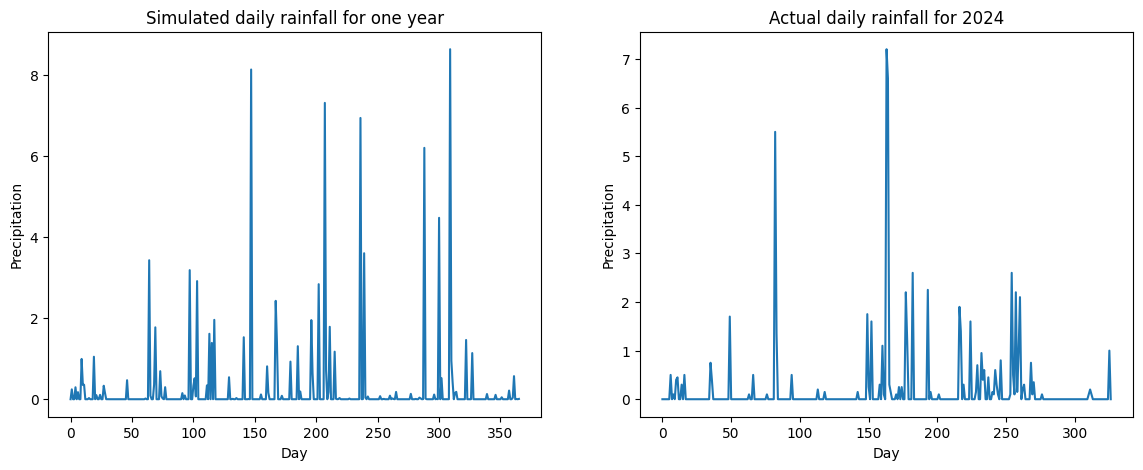

In [85]:
#Plot the simulated rainfall each day for next one year and actual rainfall for the year 2024
if __name__=='__main__':

    fig, axes = plt.subplots(1,2,figsize=(14,5))
    #Plot simulated rainfall for the final simulation
    axes[0].plot(rainfall_amounts[999])
    axes[0].set_title('Simulated daily rainfall for one year')
    axes[0].set_xlabel('Day')
    axes[0].set_ylabel('Precipitation')
    #plot the actual rainfall for the year 2024
    axes[1].plot(rainfall_data_ts[rainfall_data_ts[' YEAR']==2024].reset_index()[' PRECIPITATION'])
    axes[1].set_title('Actual daily rainfall for 2024')
    axes[1].set_xlabel('Day')
    axes[1].set_ylabel('Precipitation')

The actual vs simulated rainfall shows we might be overestimating the tails because of heavy tail tweedie distribution. 

A better appraoch maybe to create a model with occurence of rain modelled as a discrete distibrution like bernoulli and rain severity as a gamma distriution. 
We are also not able to model the fact that given it rains on a certain day it is more likely to rain the next day instead of modelling rainfall completely randomly. 

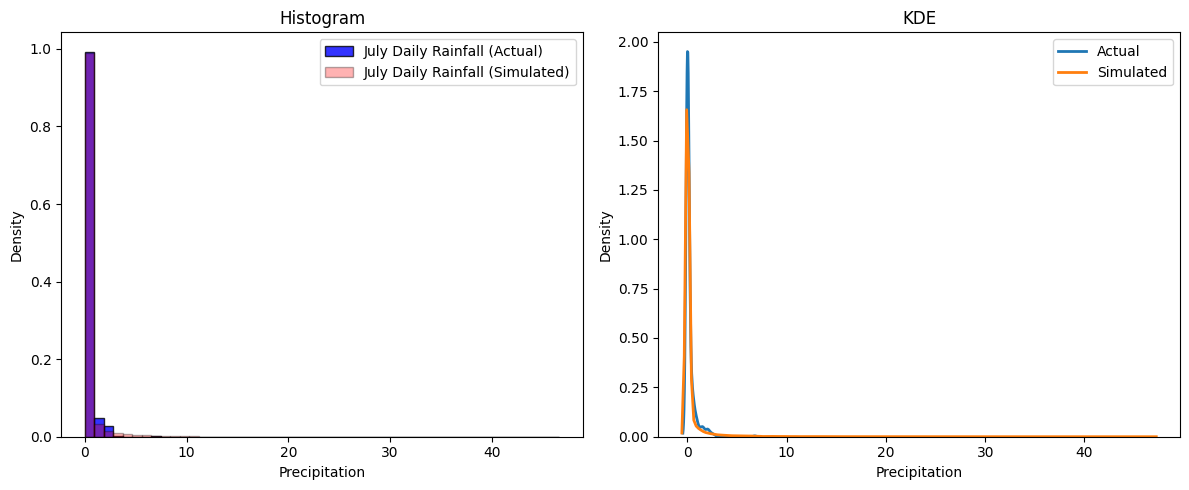

In [86]:
if __name__=='__main__':
    #Distirbution of daily rainfall in July for actual dataset (for)
    simulated_in_july = rainfall_amounts[:,182:214].flatten()
    actual_in_july = rainfall_data_ts[rainfall_data_ts[' MONTH']==7][' PRECIPITATION']

    combined = np.concatenate([actual_in_july, simulated_in_july])
    bins = np.histogram_bin_edges(combined, bins=50)

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    #Plot the Histogram
    axes[0].hist(actual_in_july, bins=bins, density=True, edgecolor='black', label='July Daily Rainfall (Actual)', alpha=0.8, color='b')
    axes[0].hist(simulated_in_july, bins=bins, edgecolor='black', density=True, label='July Daily Rainfall (Simulated)', alpha=0.3, color='r')
    axes[0].legend()
    axes[0].set_title('Histogram')
    axes[0].set_xlabel('Precipitation')
    axes[0].set_ylabel('Density')

    #Plot the KDE
    sns.kdeplot(actual_in_july, ax=axes[1], label='Actual', linewidth=2)
    sns.kdeplot(simulated_in_july, ax=axes[1], label='Simulated', linewidth=2)
    axes[1].set_title('KDE')
    axes[1].set_xlabel('Precipitation')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

The model captures the overall distributional characteristics of rainfall, including skewness and concentration near lower values. However, the simulated distribution exhibits a slightly heavier tail, indicating a tendency to overestimate extreme rainfall events, as we already expected.

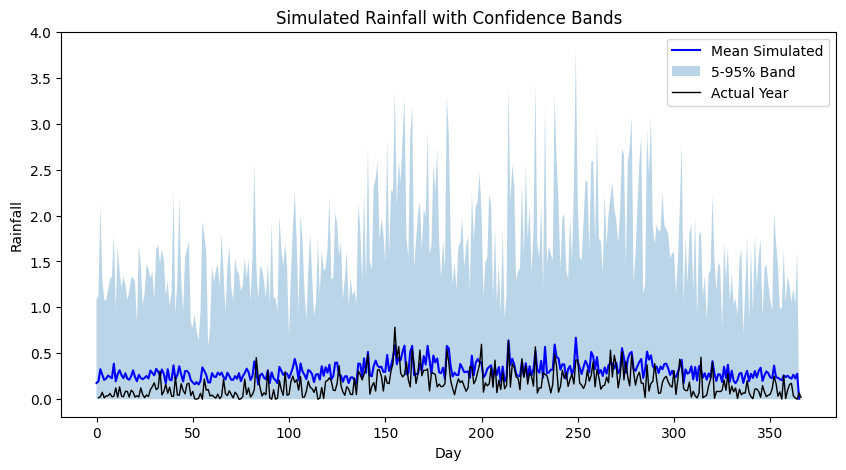

In [87]:
if __name__=='__main__':
    #Plotting the mean simulated and actual rainfalls
    mean_sim = rainfall_amounts.mean(axis=0)
    p5 = np.percentile(rainfall_amounts, 5, axis=0)
    p95 = np.percentile(rainfall_amounts, 95, axis=0)

    actual_mean = rainfall_data_ts.groupby(' DAY_OF_YEAR')[' PRECIPITATION'].mean()
    plt.figure(figsize=(10,5))
    plt.plot(mean_sim, label='Mean Simulated', color='blue')
    plt.fill_between(range(len(mean_sim)), p5, p95, alpha=0.3, label='5-95% Band')
    plt.plot(actual_mean, label='Actual Year', color='black', linewidth=1)
    plt.xlabel('Day')
    plt.ylabel('Rainfall')
    plt.title('Simulated Rainfall with Confidence Bands')
    plt.legend()
    plt.show()

The simulated mean rainfall captures the seasonal pattern observed in the data, with similar temporal variation across the year. However, the model slightly overestimates average rainfall levels, and the simulated variability remains broader than observed, indicating potential over-dispersion in the model.

In [ ]:
#Aggregating rainfalls for each month (we use this in final insurance loss simulation notebook)
month_lengths = [31,28,31,30,31,30,31,31,30,31,30,31]

monthly_rainfall = []
start = 0

for days in month_lengths:
    monthly_rainfall.append(rainfall_amounts[:, start:start+days].sum(axis=1))
    start += days

monthly_rainfall = np.column_stack(monthly_rainfall)

### End of Notebook